In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans

In [ ]:
# Load the dataset
df = pd.read_csv('Live.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

In [ ]:
# Drop unnecessary columns
columns_to_drop = ['Column1', 'Column2', 'Column3', 'Column4', 'status_id', 'status_published']
df_clean = df.drop(columns=columns_to_drop)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print(f"\nDataset after cleaning: {df_clean.shape}")

# Display information about the cleaned dataset
print("\nCleaned dataset info:")
df_clean.info()

In [ ]:
# Separate features (x) and target (y)
x = df_clean.copy()
y = df_clean['status_type']

# Encode the categorical 'status_type' column
le = LabelEncoder()
x['status_type'] = le.fit_transform(x['status_type'])
y_encoded = le.transform(y)

# Display the mapping of status types to numbers
print("\nStatus type mapping:")
for i, status_type in enumerate(le.classes_):
    print(f"{status_type}: {i}")

In [ ]:
# Normalize the data
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# Convert back to DataFrame for better readability
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
print("\nFirst few rows of scaled data:")
print(x_scaled_df.head())

In [11]:
# Apply K-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(x_scaled)

# Evaluate the clustering results
labels = kmeans.labels_
correct_labels = sum(y_encoded == labels)
accuracy = correct_labels / y_encoded.size

print(f"\nClustering results with 2 clusters:")
print(f"{correct_labels} out of {y_encoded.size} samples were correctly labeled.")
print(f"Accuracy score: {accuracy:.2f}")


Clustering results with 2 clusters:
2707 out of 4987 samples were correctly labeled.
Accuracy score: 0.54


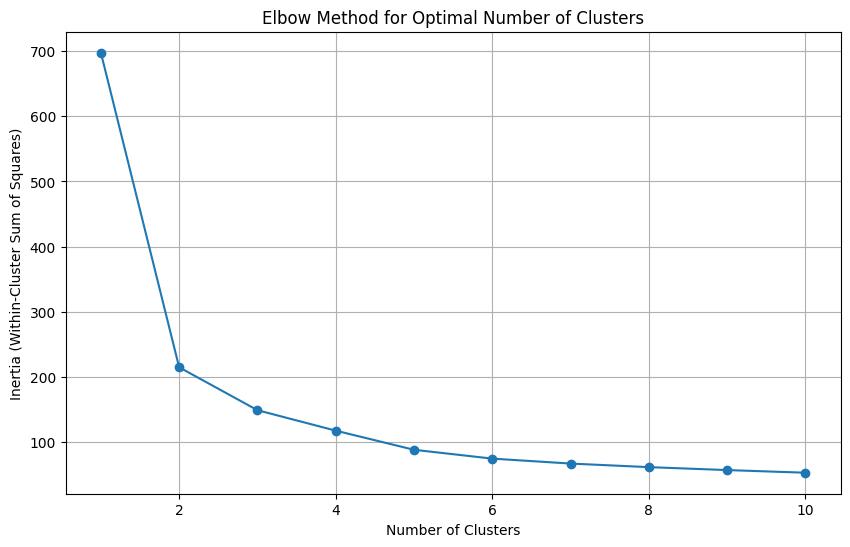

In [12]:
# Find the optimal number of clusters using the Elbow Method
inertia_values = []
cluster_range = range(1, 11)

for i in cluster_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(x_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [ ]:
# Apply K-means with the optimal number of clusters
optimal_clusters = 4  # Adjust this based on the elbow plot
kmeans_optimal = KMeans(n_clusters=optimal_clusters, random_state=0)
kmeans_optimal.fit(x_scaled)

# Evaluate the new clustering results
optimal_labels = kmeans_optimal.labels_
optimal_correct = sum(y_encoded == optimal_labels)
optimal_accuracy = optimal_correct / y_encoded.size

print(f"\nClustering results with {optimal_clusters} clusters:")
print(f"{optimal_correct} out of {y_encoded.size} samples were correctly labeled.")
print(f"Accuracy score: {optimal_accuracy:.2f}")

In [ ]:
# Display cluster centers
cluster_centers = scaler.inverse_transform(kmeans_optimal.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=x.columns)
print("\nCluster centers (original scale):")
print(cluster_centers_df)